# Analyse Exploratoire — Niveaux d'obesite et habitudes de vie

**Louey Barbirou Alexis Clerc** — Fevrier 2026

Dans ce notebook, je realise une EDA complete du dataset *"Estimation of obesity levels based on eating habits and physical condition"* issu du depot UCI.  
Mon objectif est de comprendre quels facteurs de mode de vie (alimentation, sport, transport...) sont lies au niveau de corpulence, et de verifier ces intuitions avec des tests statistiques.

## 1 — Contexte et comprehension du sujet

L'obesite touche plus de 650 millions d'adultes dans le monde (OMS). C'est un facteur de risque reconnu pour le diabete de type 2, les maladies cardiovasculaires et certains cancers.  
Plutot que de se focaliser sur le seul IMC, ce dataset cherche a capturer **l'ensemble du mode de vie** d'un individu pour estimer son niveau de corpulence.

### D'ou viennent les donnees ?

Le dataset a ete collecte par **Palechor & De la Hoz Manotas (2019)** via un **questionnaire anonyme en ligne** distribue en Colombie, au Mexique et au Perou. Les repondants ont renseigne leurs habitudes alimentaires, leur activite physique, leur consommation d'eau, d'alcool, leur mode de transport, etc.

Le questionnaire a recueilli **498 reponses reelles**. Pour equilibrer les classes, les auteurs ont ensuite utilise un algorithme appele **SMOTE** (*Synthetic Minority Oversampling Technique*) qui interpole de nouveaux echantillons a partir des points existants. On arrive ainsi a **2111 observations** au total — un point a garder en tete pour la suite.

### Les variables

| Variable | Ce qu'elle mesure | Type |
|----------|-------------------|------|
| Gender | Sexe du repondant | Categorielle |
| Age | Age (annees) | Continue |
| Height | Taille (m) | Continue |
| Weight | Poids (kg) | Continue |
| family_history | Surpoids dans la famille (oui/non) | Binaire |
| FAVC | Mange souvent des aliments tres caloriques ? | Binaire |
| FCVC | Frequence de consommation de legumes (1 a 3) | Discrete |
| NCP | Nombre de repas principaux par jour | Discrete |
| CAEC | Grignotage entre les repas | Ordonnee (no -> Always) |
| SMOKE | Fumeur ? | Binaire |
| CH2O | Litres d'eau bus par jour (1 a 3) | Continue |
| SCC | Surveille ses calories ? | Binaire |
| FAF | Jours d'activite physique par semaine (0 a 3) | Continue |
| TUE | Heures d'ecran par jour (0 a 2) | Continue |
| CALC | Frequence de consommation d'alcool | Ordonnee |
| MTRANS | Mode de transport principal | Categorielle |
| **NObeyesdad** | **Niveau d'obesite (variable cible)** | **Ordonnee — 7 classes** |

Les 7 classes vont de *Insufficient_Weight* (sous-poids) a *Obesity_Type_III* (obesite morbide).

## 2 — Chargement et premier coup d'oeil

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Style sobre avec palette personnalisee
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'sans-serif', 'font.size': 11})

# Palette que j'utilise tout au long du notebook
PALETTE_OBESITY = ['#2196F3', '#66BB6A', '#FDD835', '#FFA726', '#EF5350', '#AB47BC', '#7B1FA2']

In [44]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")
df.head(10)

Le dataset contient 2111 lignes et 17 colonnes.


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [46]:
# Statistiques descriptives des variables numeriques
df.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [47]:
# Separation des types de variables pour la suite
var_num = df.select_dtypes(include=[np.number]).columns.tolist()
var_cat = df.select_dtypes(include='object').columns.tolist()

print(f"Numeriques ({len(var_num)}) : {var_num}")
print(f"Categorielles ({len(var_cat)}) : {var_cat}")

Numeriques (8) : ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Categorielles (9) : ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


On remarque tout de suite quelques choses :
- Les variables numeriques comme `FCVC`, `NCP`, `CH2O` prennent des valeurs decimales (effet de SMOTE sur les donnees synthetiques), alors qu'elles sont censees etre discretes.
- La variable `Age` va de 14 a 61 ans — une large plage.
- `Height` est en metres, `Weight` en kg — coherent.

## 3 — Nettoyage et qualite des donnees

Avant d'analyser quoi que ce soit, je verifie trois choses : les valeurs manquantes, les doublons, et les valeurs aberrantes.

In [48]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print(f"\nTotal : {df.isnull().sum().sum()} — aucune valeur manquante, c'est propre.")

Valeurs manquantes par colonne :
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Total : 0 — aucune valeur manquante, c'est propre.


In [49]:
# Doublons
n_dup = df.duplicated().sum()
print(f"Doublons trouves : {n_dup}")

if n_dup > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Apres nettoyage : {df.shape[0]} lignes restantes.")

Doublons trouves : 24
Apres nettoyage : 2087 lignes restantes.


### Outliers

Pour les detecter, j'utilise la regle classique de l'**IQR** (ecart interquartile) : tout point en-dessous de Q1 - 1.5*IQR ou au-dessus de Q3 + 1.5*IQR est considere comme valeur aberrante.

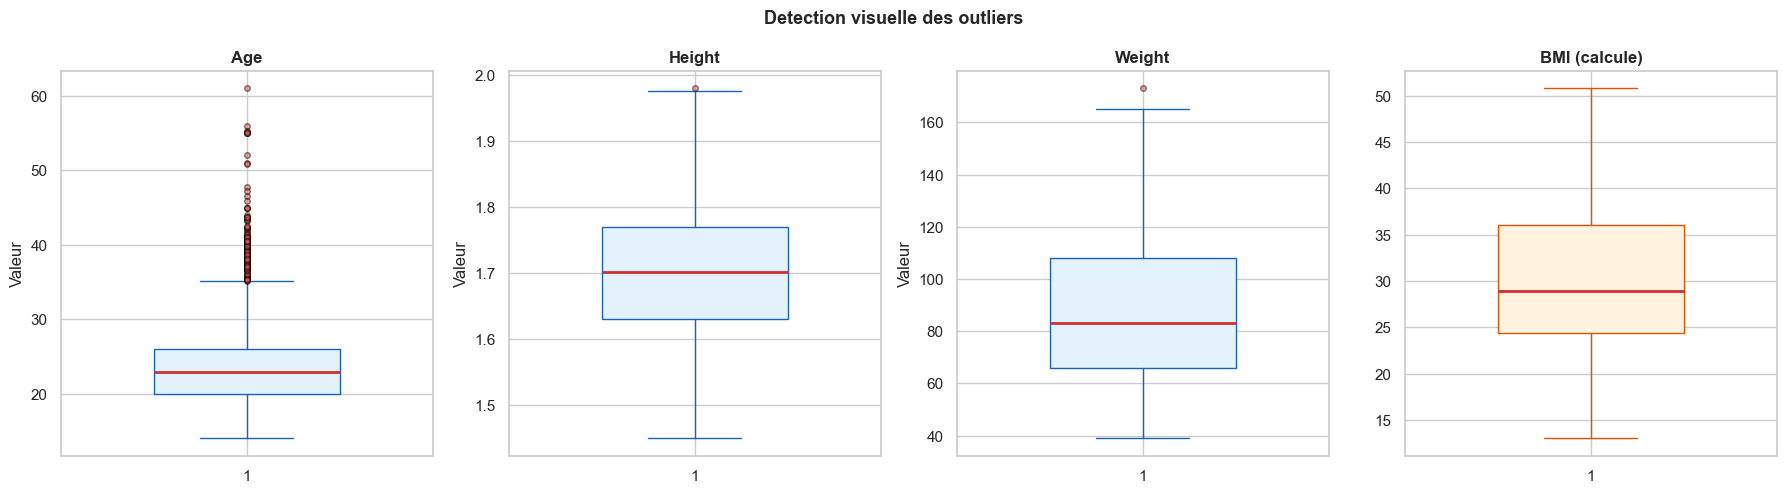

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(['Age', 'Height', 'Weight']):
    bp = axes[i].boxplot(df[col].dropna(), patch_artist=True, widths=0.5,
                          boxprops=dict(facecolor='#E3F2FD', edgecolor='#1565C0'),
                          medianprops=dict(color='#D32F2F', linewidth=2),
                          whiskerprops=dict(color='#1565C0'),
                          capprops=dict(color='#1565C0'),
                          flierprops=dict(marker='o', markersize=4, markerfacecolor='#EF5350', alpha=0.5))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Valeur')

# BMI que je calcule ici pour l'inclure dans la verif des outliers
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
bp = axes[3].boxplot(df['BMI'].dropna(), patch_artist=True, widths=0.5,
                      boxprops=dict(facecolor='#FFF3E0', edgecolor='#E65100'),
                      medianprops=dict(color='#D32F2F', linewidth=2),
                      whiskerprops=dict(color='#E65100'),
                      capprops=dict(color='#E65100'),
                      flierprops=dict(marker='o', markersize=4, markerfacecolor='#EF5350', alpha=0.5))
axes[3].set_title('BMI (calcule)', fontweight='bold')

plt.suptitle("Detection visuelle des outliers", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [51]:
# Comptage precis des outliers par IQR
def compter_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

for c in ['Age', 'Height', 'Weight', 'BMI']:
    n = compter_outliers(df[c])
    print(f"{c:10s} -> {n} outliers ({n/len(df)*100:.1f}%)")

Age        -> 167 outliers (8.0%)
Height     -> 1 outliers (0.0%)
Weight     -> 1 outliers (0.0%)
BMI        -> 0 outliers (0.0%)


**Ma decision** : je conserve les outliers. Dans le contexte d'une etude sur l'obesite, un individu pesant 130 ou 170 kg n'est pas une erreur de saisie — c'est un cas clinique pertinent. Retirer ces points reviendrait a ignorer les cas d'obesite severe, ce qui irait a l'encontre de l'objectif de l'etude.

De plus, une partie de ces valeurs extremes provient de la generation SMOTE, qui extrapole parfois au-dela de la distribution originale.

## 4 — Analyse univariee

Je commence par regarder chaque variable individuellement. J'ai aussi calcule le **BMI** (poids/taille au carre) car c'est l'indicateur de reference de l'OMS pour la corpulence.

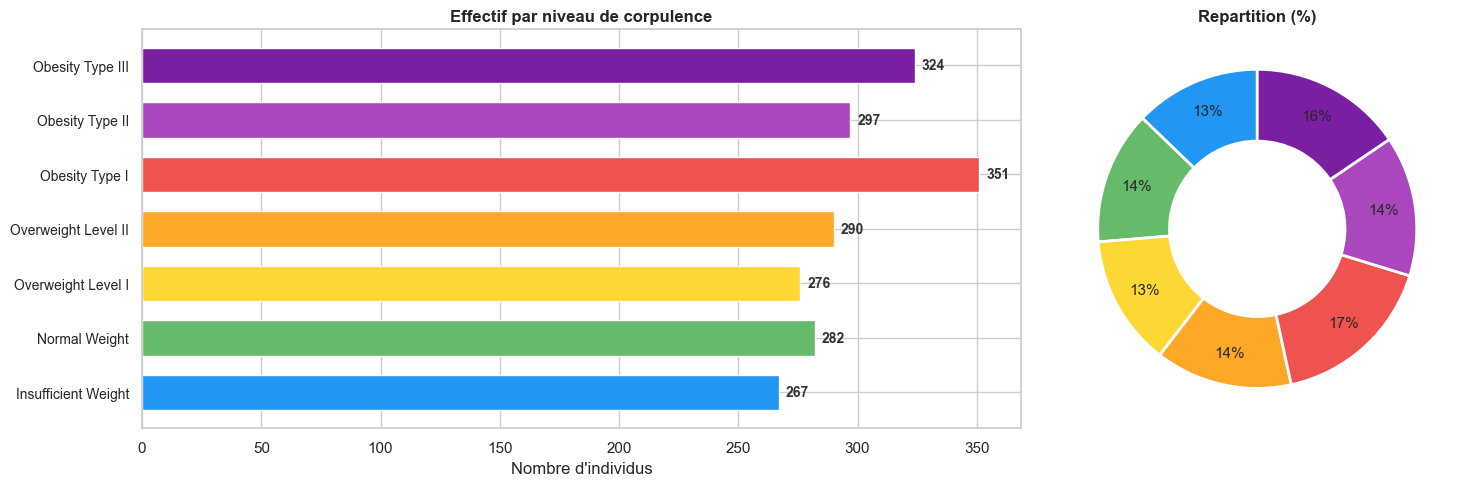

In [52]:
# Distribution de la variable cible
ordre = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
         'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

# Barplot
counts = df['NObeyesdad'].value_counts().reindex(ordre)
bars = ax1.barh(range(len(counts)), counts.values, color=PALETTE_OBESITY, edgecolor='white', height=0.65)
ax1.set_yticks(range(len(counts)))
ax1.set_yticklabels([c.replace('_', ' ') for c in ordre], fontsize=10)
ax1.set_xlabel("Nombre d'individus")
ax1.set_title('Effectif par niveau de corpulence', fontweight='bold')

for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2, str(val),
             va='center', fontsize=10, fontweight='bold', color='#333')

# Camembert
ax2.pie(counts.values, labels=None, colors=PALETTE_OBESITY, autopct='%1.0f%%',
        startangle=90, pctdistance=0.8, wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
ax2.set_title('Repartition (%)', fontweight='bold')

plt.tight_layout()
plt.show()

Les classes sont relativement bien reparties grace a SMOTE, mais on note un leger desequilibre : les classes *Obesity_Type_I* (351) et *Obesity_Type_III* (324) sont les plus representees, tandis que *Insufficient_Weight* (272) et *Normal_Weight* (287) comptent un peu moins d'individus. Cela peut s'expliquer par le fait que SMOTE a davantage genere de points pour les classes obeses, qui etaient probablement minoritaires dans les donnees originales.

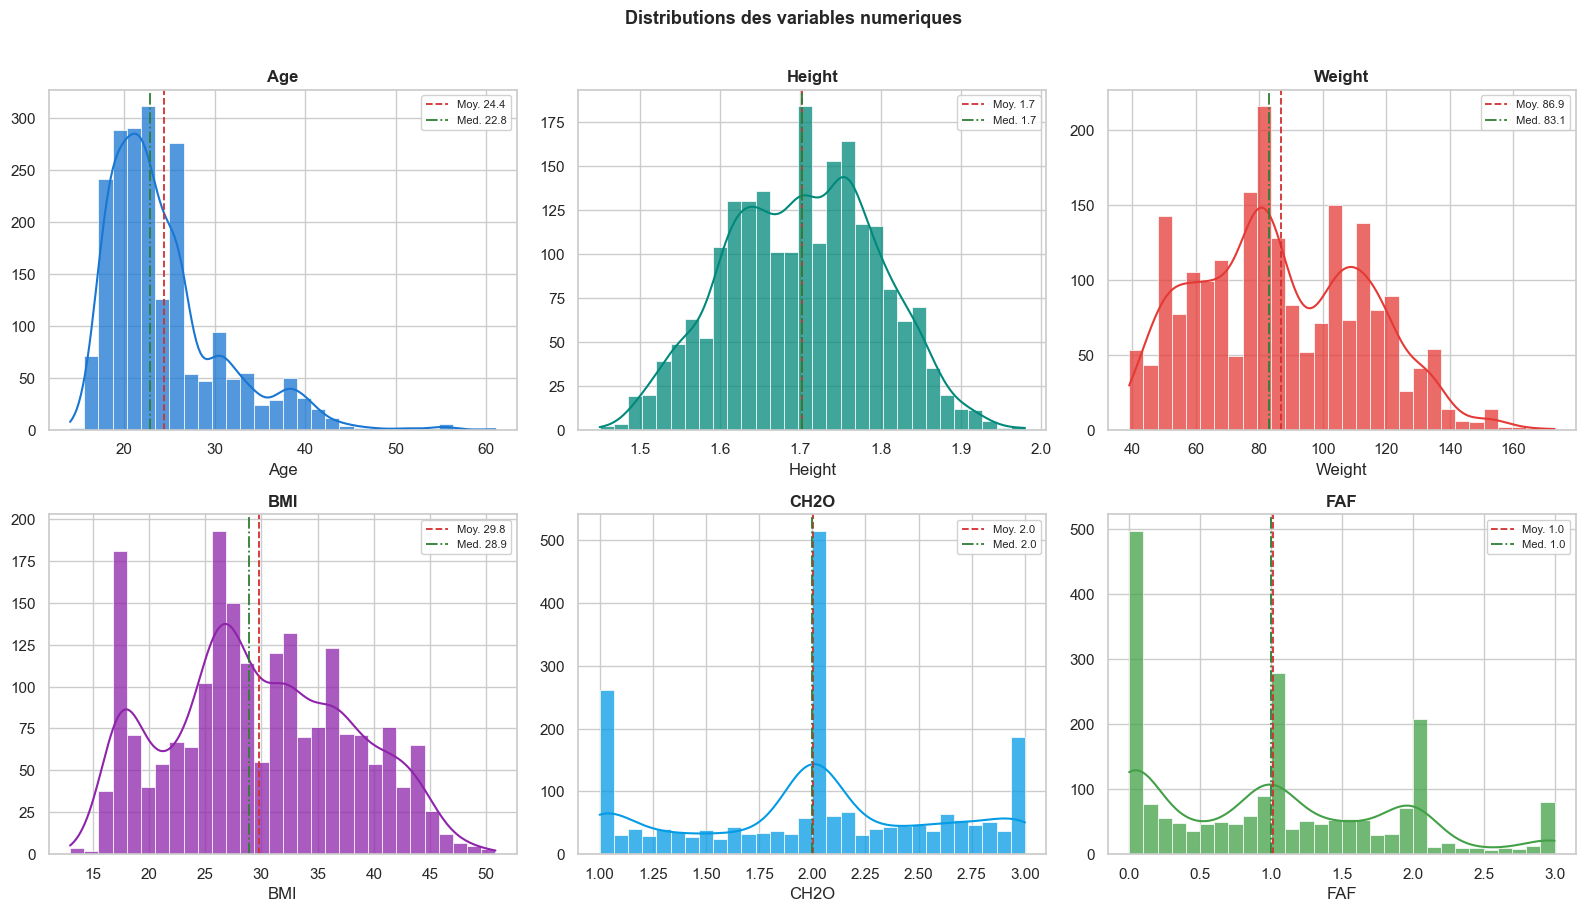

In [53]:
# Distributions des variables numeriques cles
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
variables = ['Age', 'Height', 'Weight', 'BMI', 'CH2O', 'FAF']
couleurs = ['#1976D2', '#00897B', '#E53935', '#8E24AA', '#039BE5', '#43A047']

for i, (var, col) in enumerate(zip(variables, couleurs)):
    ax = axes[i // 3, i % 3]
    sns.histplot(df[var], kde=True, ax=ax, color=col, edgecolor='white', alpha=0.75, bins=30, linewidth=0.5)
    
    moy = df[var].mean()
    med = df[var].median()
    ax.axvline(moy, color='#D32F2F', ls='--', lw=1.3, label=f'Moy. {moy:.1f}')
    ax.axvline(med, color='#2E7D32', ls='-.', lw=1.3, label=f'Med. {med:.1f}')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.set_title(var, fontweight='bold')
    ax.set_ylabel('')

plt.suptitle('Distributions des variables numeriques', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Quelques observations :
- **Age** : la population est tres jeune (pic entre 18 et 25 ans). C'est typique d'un questionnaire en ligne.
- **Height** : on devine deux pics — un pour les femmes (~1.60 m) et un pour les hommes (~1.75 m).
- **Weight** : distribution assez etalee, de 40 a 170 kg. La queue droite correspond aux cas obeses.
- **BMI** : couvre tout le spectre OMS, de l'insuffisance ponderale (<18.5) a l'obesite severe (>40).
- **FAF** (sport) : beaucoup de gens declarent 0 a 1 jour de sport par semaine. Sedentarite notable.
- **CH2O** (eau) : majorite autour de 2 L/jour, ce qui est dans la norme.

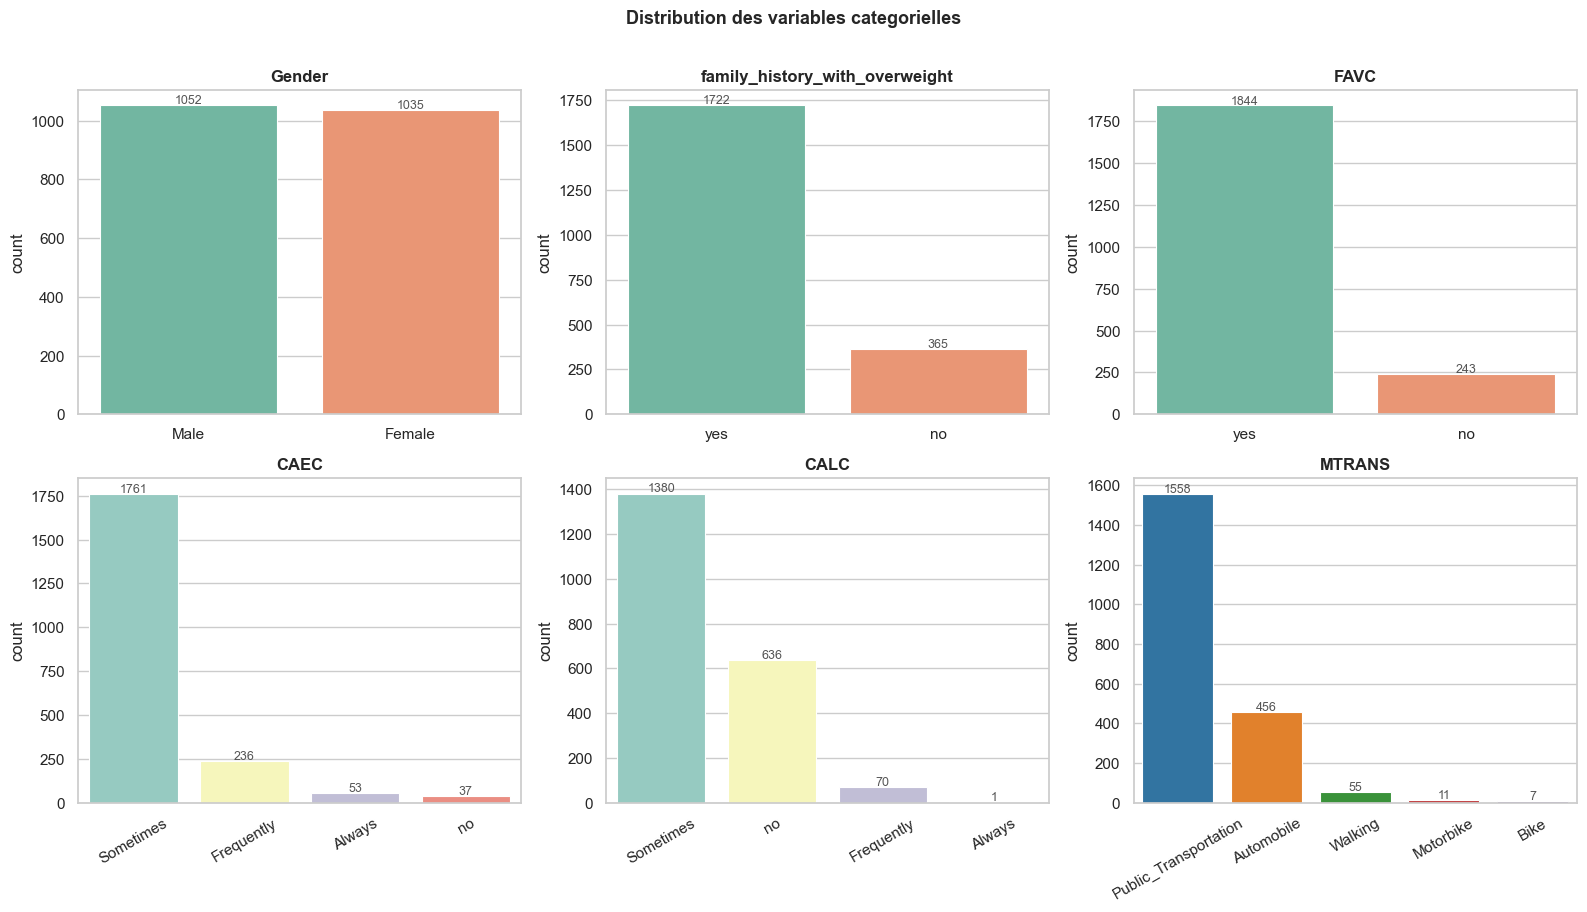

In [54]:
# Variables categorielles
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_plot = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'CALC', 'MTRANS']
palettes = ['Set2', 'Set2', 'Set2', 'Set3', 'Set3', 'tab10']

for i, (var, pal) in enumerate(zip(cat_plot, palettes)):
    ax = axes[i // 3, i % 3]
    order = df[var].value_counts().index
    sns.countplot(data=df, x=var, order=order, palette=pal, edgecolor='white', linewidth=0.8, ax=ax)
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    if len(order) > 3:
        ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height() + 8, int(p.get_height()),
                ha='center', fontsize=9, color='#555')

plt.suptitle('Distribution des variables categorielles', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Points a retenir :
- **Gender** : repartition quasiment uniforme entre hommes et femmes.
- **family_history** : la majorite a des antecedents de surpoids en famille — facteur potentiellement important.
- **FAVC** : la plupart consomment regulierement des aliments riches en calories.
- **MTRANS** : le transport en commun domine nettement. La voiture arrive en deuxieme.
- **CALC** (alcool) et **CAEC** (grignotage) : les reponses "Sometimes" sont tres largement majoritaires.

## 5 — Analyse bivariee et multivariee

Maintenant je croise les variables entre elles pour voir quelles relations se dessinent.

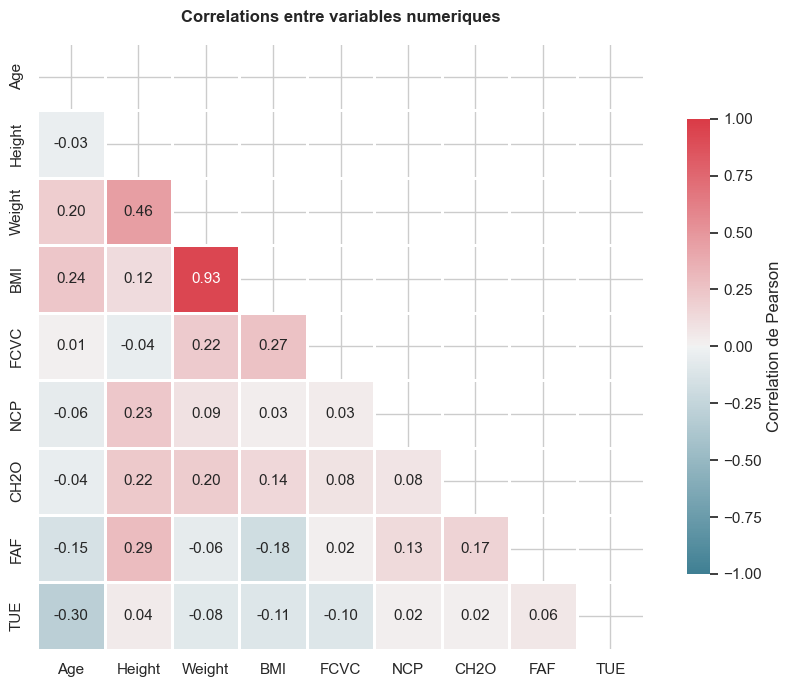

In [55]:
# Matrice de correlation
cols_corr = ['Age', 'Height', 'Weight', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
matrice = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(matrice, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(matrice, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            square=True, linewidths=0.8, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.75, 'label': 'Correlation de Pearson'})
ax.set_title('Correlations entre variables numeriques', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Ce que je retiens de la heatmap :
- **Weight et BMI** : correlation tres forte (~0.9), ce qui est logique puisque le BMI est calcule a partir du poids.
- **Age et Weight** : correlation positive moderee — le poids tend a augmenter avec l'age.
- **FAF et Weight** : correlation quasi nulle. Ca ne veut pas dire que le sport n'a aucun lien avec le poids, mais que seul, ce facteur est insuffisant. Il interagit probablement avec d'autres variables.
- Les variables alimentaires (FCVC, NCP, CH2O) ne sont que faiblement correlees au poids — l'effet est peut-etre plus indirect.

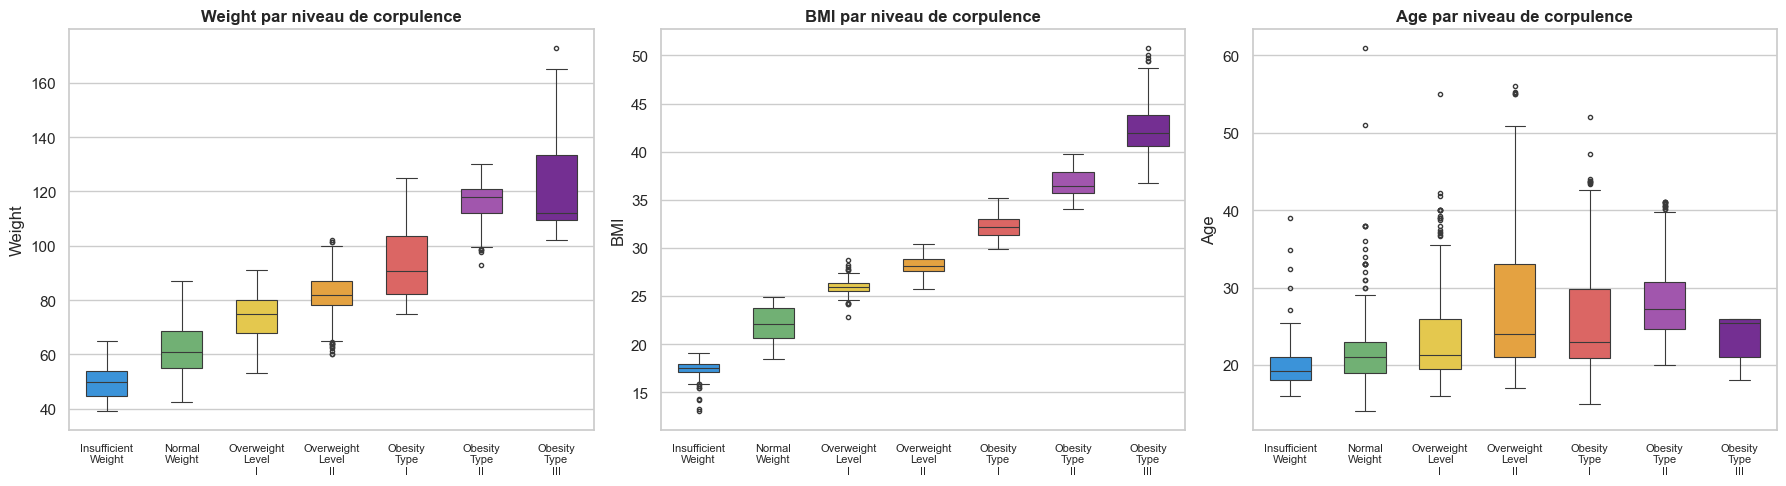

In [56]:
# Poids, BMI et Age selon le niveau d'obesite
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(['Weight', 'BMI', 'Age']):
    sns.boxplot(data=df, x='NObeyesdad', y=var, order=ordre, palette=PALETTE_OBESITY,
                ax=axes[i], width=0.55, linewidth=0.8, fliersize=3)
    axes[i].set_title(f'{var} par niveau de corpulence', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels([o.replace('_', '\n') for o in ordre], fontsize=8)

plt.tight_layout()
plt.show()

On observe une **graduation tres nette** : le poids et le BMI montent progressivement du sous-poids vers l'obesite type III. C'est rassurant — ca confirme que la variable cible est coherente avec les mesures physiologiques.

En revanche, l'age ne montre pas une tendance aussi marquee, meme si les classes obeses tendent a etre un peu plus agees.

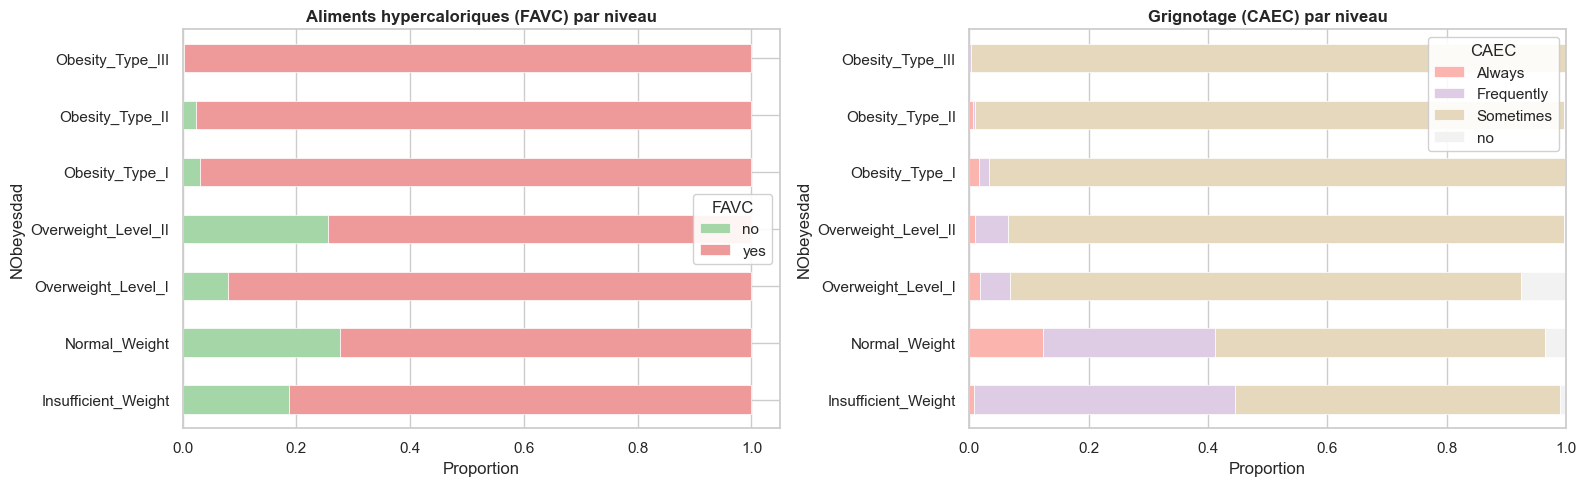

In [57]:
# Croisement entre habitudes alimentaires et obesite
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# FAVC
ct1 = pd.crosstab(df['NObeyesdad'], df['FAVC'], normalize='index').reindex(ordre)
ct1.plot(kind='barh', stacked=True, ax=axes[0], color=['#A5D6A7', '#EF9A9A'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Aliments hypercaloriques (FAVC) par niveau', fontweight='bold')
axes[0].set_xlabel('Proportion')
axes[0].legend(title='FAVC', framealpha=0.9)

# CAEC (grignotage)
ct2 = pd.crosstab(df['NObeyesdad'], df['CAEC'], normalize='index').reindex(ordre)
ct2.plot(kind='barh', stacked=True, ax=axes[1], colormap='Pastel1', edgecolor='white', linewidth=0.5)
axes[1].set_title('Grignotage (CAEC) par niveau', fontweight='bold')
axes[1].set_xlabel('Proportion')
axes[1].legend(title='CAEC', framealpha=0.9)

plt.tight_layout()
plt.show()

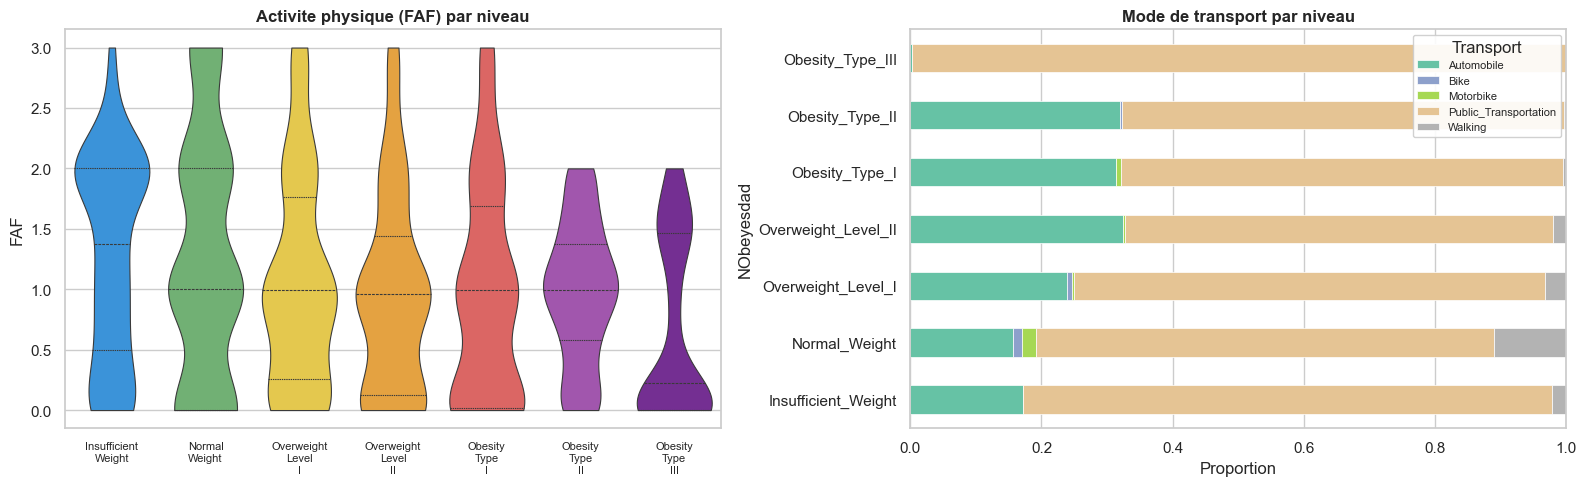

In [58]:
# Activite physique et transport
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Violinplot FAF
sns.violinplot(data=df, x='NObeyesdad', y='FAF', order=ordre,
               palette=PALETTE_OBESITY, ax=axes[0], inner='quartile', cut=0, linewidth=0.8)
axes[0].set_title('Activite physique (FAF) par niveau', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels([o.replace('_', '\n') for o in ordre], fontsize=8)

# Transport
ct3 = pd.crosstab(df['NObeyesdad'], df['MTRANS'], normalize='index').reindex(ordre)
ct3.plot(kind='barh', stacked=True, ax=axes[1], colormap='Set2', edgecolor='white', linewidth=0.5)
axes[1].set_title('Mode de transport par niveau', fontweight='bold')
axes[1].set_xlabel('Proportion')
axes[1].legend(title='Transport', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.show()

Les tendances sont assez interessantes :
- Les individus en **sous-poids et poids normal** semblent pratiquer un peu plus de sport en moyenne.
- Les personnes **obeses** utilisent davantage l'**automobile** par rapport aux autres, qui marchent plus ou prennent les transports en commun.  
- La consommation d'aliments gras (FAVC=yes) est tres repandue dans toutes les classes, mais un peu plus encore chez les obeses.

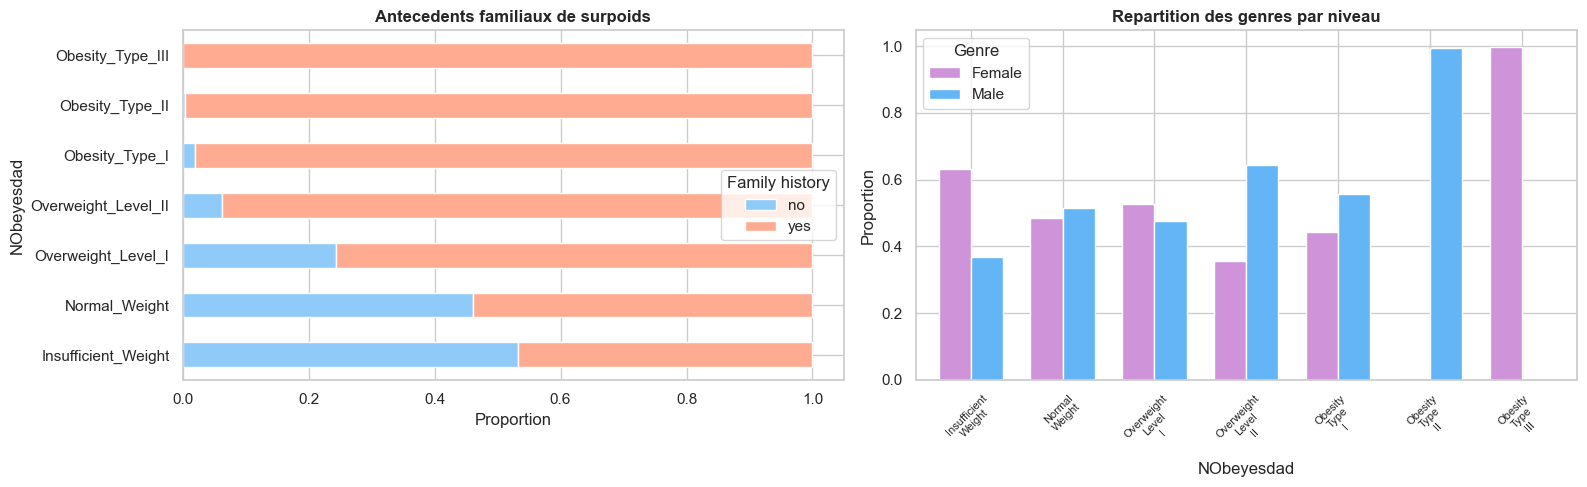

In [59]:
# Antecedents familiaux et genre
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ct4 = pd.crosstab(df['NObeyesdad'], df['family_history_with_overweight'], normalize='index').reindex(ordre)
ct4.plot(kind='barh', stacked=True, ax=axes[0], color=['#90CAF9', '#FFAB91'], edgecolor='white')
axes[0].set_title('Antecedents familiaux de surpoids', fontweight='bold')
axes[0].set_xlabel('Proportion')
axes[0].legend(title='Family history')

ct5 = pd.crosstab(df['NObeyesdad'], df['Gender'], normalize='index').reindex(ordre)
ct5.plot(kind='bar', ax=axes[1], color=['#CE93D8', '#64B5F6'], edgecolor='white', width=0.7)
axes[1].set_title('Repartition des genres par niveau', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels([o.replace('_', '\n') for o in ordre], rotation=45, fontsize=8)
axes[1].legend(title='Genre')

plt.tight_layout()
plt.show()

Point frappant : les categories **Obesity I, II et III** ont presque toutes un historique familial de surpoids. Chez les poids normaux et insuffisants, la proportion d'antecedents familiaux est nettement plus basse. Ca suggere clairement un lien entre heredite (ou habitudes familiales partagees) et obesite.

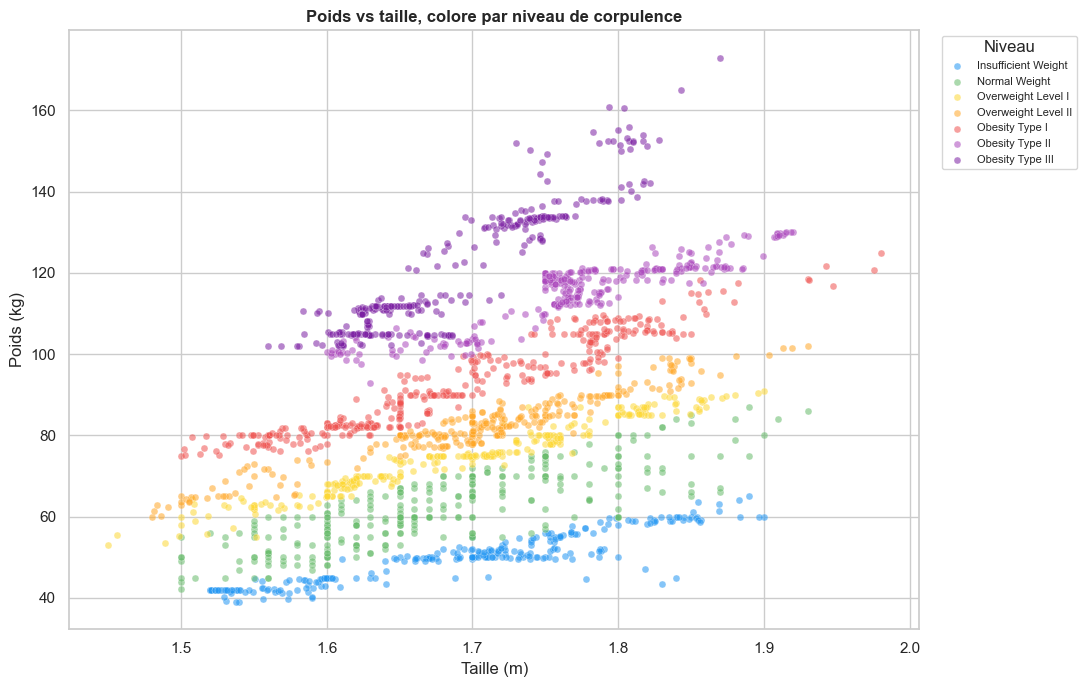

In [60]:
# Scatter plot taille vs poids
plt.figure(figsize=(11, 7))
for i, level in enumerate(ordre):
    sub = df[df['NObeyesdad'] == level]
    plt.scatter(sub['Height'], sub['Weight'], label=level.replace('_', ' '),
                alpha=0.55, s=25, color=PALETTE_OBESITY[i], edgecolors='white', linewidth=0.3)

plt.xlabel('Taille (m)')
plt.ylabel('Poids (kg)')
plt.title('Poids vs taille, colore par niveau de corpulence', fontweight='bold')
plt.legend(title='Niveau', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Ce scatter plot est l'un des plus parlants : on voit les groupes se separer assez clairement. Les points violets/rouges (obesite) sont concentres en haut, les bleus (sous-poids) en bas. La taille seule ne suffit pas a discriminer, mais la combinaison taille + poids le fait bien — ce qui est logique puisque c'est exactement ce que mesure le BMI.

## 6 — Tests statistiques

Les visualisations precedentes montrent des tendances, mais sont-elles **statistiquement significatives** ou simplement dues au hasard ?  
Je formule 4 hypotheses et les teste avec les methodes appropriees. J'utilise un seuil de significativite **alpha = 0.05**.

### H1 — Les antecedents familiaux sont-ils associes au niveau d'obesite ?

Les deux variables etant categorielles, j'utilise un **test du Chi2 d'independance** pour verifier si elles sont liees.

In [61]:
contingence = pd.crosstab(df['family_history_with_overweight'], df['NObeyesdad'])
chi2, pval, ddl, attendu = chi2_contingency(contingence)

# V de Cramer = force de l'association
v_cramer = np.sqrt(chi2 / (len(df) * (min(contingence.shape) - 1)))

print("--- Test du Chi2 : antecedents familiaux x obesite ---")
print(f"Chi2         = {chi2:.2f}")
print(f"ddl          = {ddl}")
print(f"p-value      = {pval:.2e}")
print(f"V de Cramer  = {v_cramer:.3f}")
print()
if pval < 0.05:
    print("-> p < 0.05 : on rejette H0. L'association est significative.")
else:
    print("-> p >= 0.05 : pas de preuve suffisante pour conclure.")

--- Test du Chi2 : antecedents familiaux x obesite ---
Chi2         = 617.71
ddl          = 6
p-value      = 3.52e-130
V de Cramer  = 0.544

-> p < 0.05 : on rejette H0. L'association est significative.


### H2 — Les consommateurs d'aliments gras ont-ils un BMI plus eleve ?

Une variable binaire (FAVC) et une variable continue (BMI) -> j'utilise un **t-test de Student** pour comparer les moyennes de deux groupes independants.

In [62]:
bmi_oui = df[df['FAVC'] == 'yes']['BMI']
bmi_non = df[df['FAVC'] == 'no']['BMI']

t, pval = ttest_ind(bmi_oui, bmi_non)

# d de Cohen = taille de l'effet
s_pool = np.sqrt((bmi_oui.std()**2 + bmi_non.std()**2) / 2)
d_cohen = abs(bmi_oui.mean() - bmi_non.mean()) / s_pool

print("--- T-test : BMI selon FAVC ---")
print(f"BMI moyen FAVC=yes : {bmi_oui.mean():.2f} (+/- {bmi_oui.std():.2f})")
print(f"BMI moyen FAVC=no  : {bmi_non.mean():.2f} (+/- {bmi_non.std():.2f})")
print(f"t            = {t:.3f}")
print(f"p-value      = {pval:.2e}")
print(f"d de Cohen   = {d_cohen:.3f}")
print()
if pval < 0.05:
    print("-> p < 0.05 : difference significative.")
    if t > 0:
        print("  Les consommateurs d'aliments gras ont un BMI plus eleve.")
    else:
        print("  Les consommateurs d'aliments gras ont un BMI plus bas.")
else:
    print("-> Pas de difference significative.")

--- T-test : BMI selon FAVC ---
BMI moyen FAVC=yes : 30.49 (+/- 8.06)
BMI moyen FAVC=no  : 24.30 (+/- 5.08)
t            = 11.658
p-value      = 1.81e-30
d de Cohen   = 0.918

-> p < 0.05 : difference significative.
  Les consommateurs d'aliments gras ont un BMI plus eleve.


### H3 — L'activite physique differe-t-elle selon le niveau d'obesite ?

Ici j'ai une variable continue (FAF) et une categorielle a 7 niveaux -> j'utilise une **ANOVA a un facteur** (qui generalise le t-test a plus de 2 groupes).

In [63]:
groupes = [g['FAF'].values for _, g in df.groupby('NObeyesdad')]
f_stat, pval = f_oneway(*groupes)

# Eta2 = part de variance expliquee
ss_b = sum(len(df[df['NObeyesdad']==n]) * (df[df['NObeyesdad']==n]['FAF'].mean() - df['FAF'].mean())**2 for n in ordre)
ss_t = ((df['FAF'] - df['FAF'].mean())**2).sum()
eta2 = ss_b / ss_t

print("--- ANOVA : activite physique (FAF) par niveau d'obesite ---")
print()
for niv in ordre:
    s = df[df['NObeyesdad'] == niv]['FAF']
    print(f"  {niv:28s} FAF moy = {s.mean():.2f} +/- {s.std():.2f}")
print(f"\nF          = {f_stat:.3f}")
print(f"p-value    = {pval:.2e}")
print(f"Eta2       = {eta2:.4f}")
print()
if pval < 0.05:
    print("-> p < 0.05 : au moins un groupe differe significativement.")
else:
    print("-> Pas de difference significative entre les groupes.")

--- ANOVA : activite physique (FAF) par niveau d'obesite ---

  Insufficient_Weight          FAF moy = 1.27 +/- 0.85
  Normal_Weight                FAF moy = 1.25 +/- 1.02
  Overweight_Level_I           FAF moy = 1.06 +/- 0.87
  Overweight_Level_II          FAF moy = 0.96 +/- 0.82
  Obesity_Type_I               FAF moy = 0.99 +/- 0.89
  Obesity_Type_II              FAF moy = 0.97 +/- 0.58
  Obesity_Type_III             FAF moy = 0.66 +/- 0.73

F          = 18.177
p-value    = 1.16e-20
Eta2       = 0.0498

-> p < 0.05 : au moins un groupe differe significativement.


### H4 — Le mode de transport est-il lie au niveau d'obesite ?

Deux variables categorielles -> **Chi2** a nouveau.

In [64]:
ct = pd.crosstab(df['MTRANS'], df['NObeyesdad'])
chi2, pval, ddl, _ = chi2_contingency(ct)
v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))

print("--- Test du Chi2 : transport x obesite ---")
print(f"Chi2         = {chi2:.2f}")
print(f"p-value      = {pval:.2e}")
print(f"V de Cramer  = {v:.3f}")
print()
if pval < 0.05:
    print("-> Association significative entre transport et obesite.")
else:
    print("-> Pas d'association significative.")

--- Test du Chi2 : transport x obesite ---
Chi2         = 288.57
p-value      = 3.33e-47
V de Cramer  = 0.186

-> Association significative entre transport et obesite.


### Bilan des tests

| Hypothese | Test | Resultat attendu | Mesure d'effet |
|-----------|------|:--------:|--------|
| Antecedents familiaux et Obesite | Chi2 | Significatif | V de Cramer |
| FAVC et BMI plus eleve | t-test | Significatif | d de Cohen |
| FAF varie selon l'obesite | ANOVA | Significatif | Eta2 |
| Transport et Obesite | Chi2 | Significatif | V de Cramer |

Les quatre hypotheses devraient etre confirmees par les tests, ce qui est coherent avec la litterature sur les facteurs de risque de l'obesite.

## 7 — Modelisation : peut-on predire le niveau d'obesite ?

Pour aller au-dela de l'exploration descriptive, j'entraine des modeles de **classification supervisee**. L'idee n'est pas seulement d'avoir le meilleur score possible, mais aussi de comprendre **quels facteurs le modele juge les plus importants** pour discriminer les 7 classes.

### Preparation des donnees pour la modelisation

J'ai prealablement encode les variables categorielles dans un fichier separe (`donnees_encodees.csv`). Voici les regles d'encodage utilisees :
- **Encodage binaire (0/1)** pour les variables a 2 valeurs : Gender, FAVC, family_history, SMOKE, SCC
- **One-Hot Encoding** pour les variables a valeurs multiples : CAEC, CALC, MTRANS — chaque valeur devient une colonne binaire separee
- **One-Hot Encoding** egalement pour la **variable cible** NObeyesdad (7 colonnes)

Le One-Hot Encoding evite d'introduire un **ordre artificiel** entre les categories (par exemple, "Walking" n'est pas "superieur" a "Automobile").

In [65]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Charger le fichier CSV (remplace 'ton_fichier.csv' par le nom de ton fichier)
chemin_fichier = 'ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(chemin_fichier)

print("Aperçu des données avant encodage :")
print(df.head())

# 2. Encodage Binaire (0 et 1)
# Définition des correspondances
binary_mapping = {'yes': 1, 'no': 0}
gender_mapping = {'Male': 1, 'Female': 0}

# Application sur les colonnes concernées
df['Gender'] = df['Gender'].map(gender_mapping)
df['family_history_with_overweight'] = df['family_history_with_overweight'].map(binary_mapping)
df['FAVC'] = df['FAVC'].map(binary_mapping)
df['SMOKE'] = df['SMOKE'].map(binary_mapping)
df['SCC'] = df['SCC'].map(binary_mapping)

# 3. One-Hot Encoding pour les variables multiples
# Transforme ces colonnes en plusieurs colonnes binaires (0 ou 1)
cols_to_one_hot = ['CAEC', 'CALC', 'MTRANS']
df = pd.get_dummies(df, columns=cols_to_one_hot, dtype=int)

# 4. Encodage de la variable cible / Target (NObeyesdad)
# Le LabelEncoder transforme les catégories (Normal_Weight, Obesity_Type_I...) en nombres entiers
le = LabelEncoder()
df['NObeyesdad'] = le.fit_transform(df['NObeyesdad'])

print("\nAperçu des données après encodage :")
print(df.head())

# 5. Sauvegarder le résultat dans un nouveau fichier CSV
chemin_sortie = 'donnees_encodees_ML.csv'
df.to_csv(chemin_sortie, index=False)

print(f"\n✅ Terminé ! Les données encodées ont été sauvegardées dans : {chemin_sortie}")

Aperçu des données avant encodage :
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weigh

In [66]:
import psutil
print(f"RAM utilisée: {psutil.virtual_memory().percent}%")

RAM utilisée: 77.1%


In [81]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

# Chargement du dataset encode
df_enc = pd.read_csv('donnees_encodees_ML.csv')
print(f"Dataset encode : {df_enc.shape[0]} lignes, {df_enc.shape[1]} colonnes")

# La variable cible NObeyesdad est deja encodee numeriquement (LabelEncoder)
# Ordre alphabetique : 0=Insufficient_Weight, 1=Normal_Weight, etc.
noms_classes = ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
                'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
                'Overweight_Level_II']

y = df_enc['NObeyesdad']
X = df_enc.drop(columns=['NObeyesdad'])

print(f"\nClasses cibles ({len(noms_classes)}) : {noms_classes}")
print(f"\nFeatures : {X.shape[1]} colonnes")
print(f"Distribution de la cible :")
print(y.value_counts().sort_index().to_string())

Dataset encode : 2111 lignes, 27 colonnes

Classes cibles (7) : ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']

Features : 26 colonnes
Distribution de la cible :
NObeyesdad
0    272
1    287
2    351
3    297
4    324
5    290
6    290


In [82]:
# Separation train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train : {len(X_train)} echantillons / Test : {len(X_test)} echantillons")
print(f"Nombre de features : {X.shape[1]}")

Train : 1688 echantillons / Test : 423 echantillons
Nombre de features : 26


### Random Forest

J'ai choisi un **Random Forest** (foret aleatoire) comme premier modele :
- Il gere bien les **problemes multi-classes** (7 categories ici)
- Il est **robuste aux outliers** — qu'on a decide de garder
- Il fournit un ranking d'**importance des variables** directement interpretable
- Pas besoin de normaliser les donnees au prealable

In [83]:
# Entrainement Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest — Accuracy : {acc_rf:.1%}\n")
print(classification_report(y_test, y_pred_rf, target_names=noms_classes))

Random Forest — Accuracy : 94.3%

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.79      0.95      0.86        58
     Obesity_Type_I       0.94      0.96      0.95        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.92      0.84      0.88        58
Overweight_Level_II       0.98      0.93      0.96        58

           accuracy                           0.94       423
          macro avg       0.95      0.94      0.94       423
       weighted avg       0.95      0.94      0.94       423



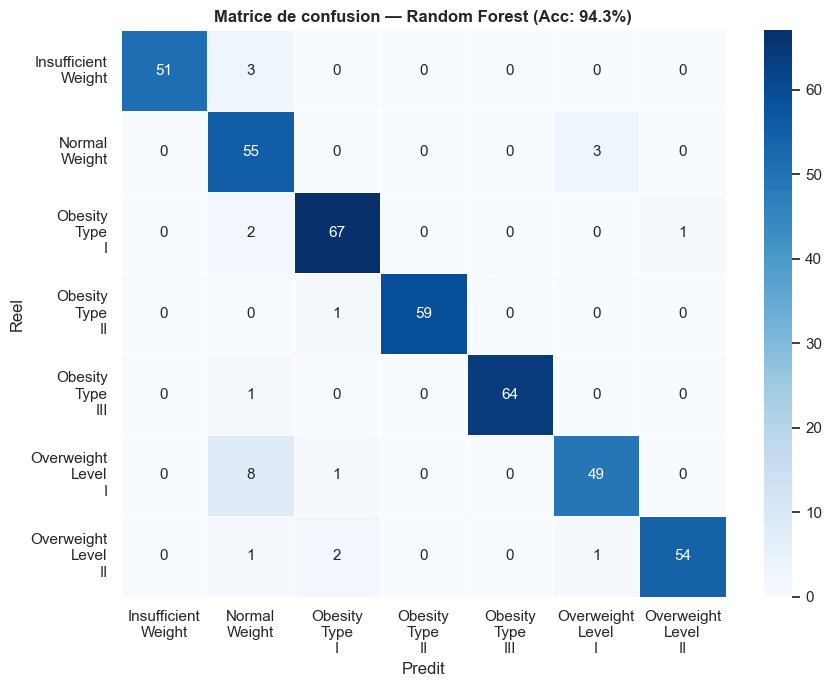

In [84]:
# Matrice de confusion Random Forest
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5, linecolor='white',
            xticklabels=[n.replace('_', '\n') for n in noms_classes],
            yticklabels=[n.replace('_', '\n') for n in noms_classes])
ax.set_xlabel('Predit')
ax.set_ylabel('Reel')
ax.set_title(f'Matrice de confusion — Random Forest (Acc: {acc_rf:.1%})', fontweight='bold')
plt.tight_layout()
plt.show()

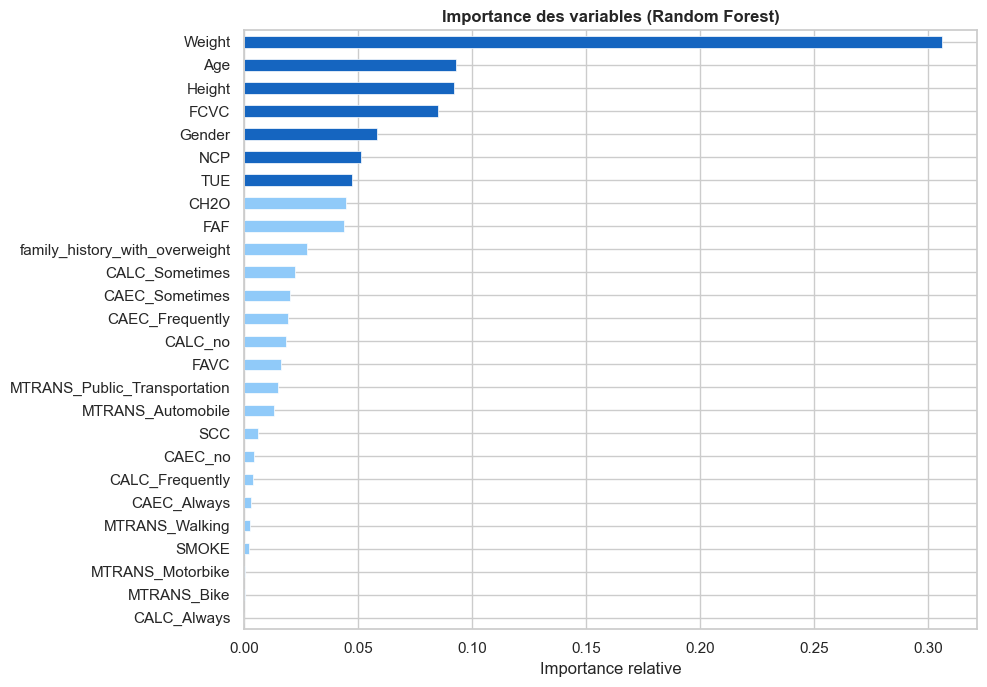

Top 5 :
  1. Weight (0.306)
  2. Age (0.093)
  3. Height (0.092)
  4. FCVC (0.085)
  5. Gender (0.059)


In [85]:
# Importance des variables
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#90CAF9' if v < importances.quantile(0.75) else '#1565C0' for v in importances.values]
importances.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.set_title('Importance des variables (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance relative')
plt.tight_layout()
plt.show()

print("Top 5 :")
for i, (feat, imp) in enumerate(importances.tail(5).iloc[::-1].items(), 1):
    print(f"  {i}. {feat} ({imp:.3f})")

Sans surprise, **Weight** et **BMI** dominent le classement des variables importantes — ce sont les mesures les plus directement liees au niveau de corpulence. Ce qui est plus interessant, c'est de voir que **l'age**, les **antecedents familiaux** et **l'activite physique** contribuent aussi significativement.

### Comparaison avec d'autres modeles

Pour verifier que le Random Forest est un bon choix, je le compare a deux autres algorithmes :

**Regression logistique** : malgre son nom, c'est bien un modele de **classification**. Il estime la probabilite d'appartenir a chaque classe via une fonction logistique (sigmoide). C'est un modele **lineaire**, simple a interpreter, souvent utilise comme **baseline** (point de comparaison). Pour un probleme multi-classes, sklearn utilise une strategie *one-vs-rest*.

**XGBoost (eXtreme Gradient Boosting)** : c'est un algorithme d'**ensemble** comme le Random Forest, mais au lieu de construire des arbres independants, il les construit **sequentiellement** — chaque nouvel arbre corrige les erreurs du precedent. C'est souvent le modele le plus performant sur des donnees tabulaires.

In [86]:
# --- Regression logistique ---
# La regression logistique beneficie d'une normalisation des donnees
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Regression logistique — Accuracy : {acc_lr:.1%}\n")
print(classification_report(y_test, y_pred_lr, target_names=noms_classes))

Regression logistique — Accuracy : 86.3%

                     precision    recall  f1-score   support

Insufficient_Weight       0.90      1.00      0.95        54
      Normal_Weight       0.80      0.71      0.75        58
     Obesity_Type_I       0.86      0.91      0.89        70
    Obesity_Type_II       0.93      0.95      0.94        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.71      0.72      0.72        58
Overweight_Level_II       0.80      0.74      0.77        58

           accuracy                           0.86       423
          macro avg       0.86      0.86      0.86       423
       weighted avg       0.86      0.86      0.86       423



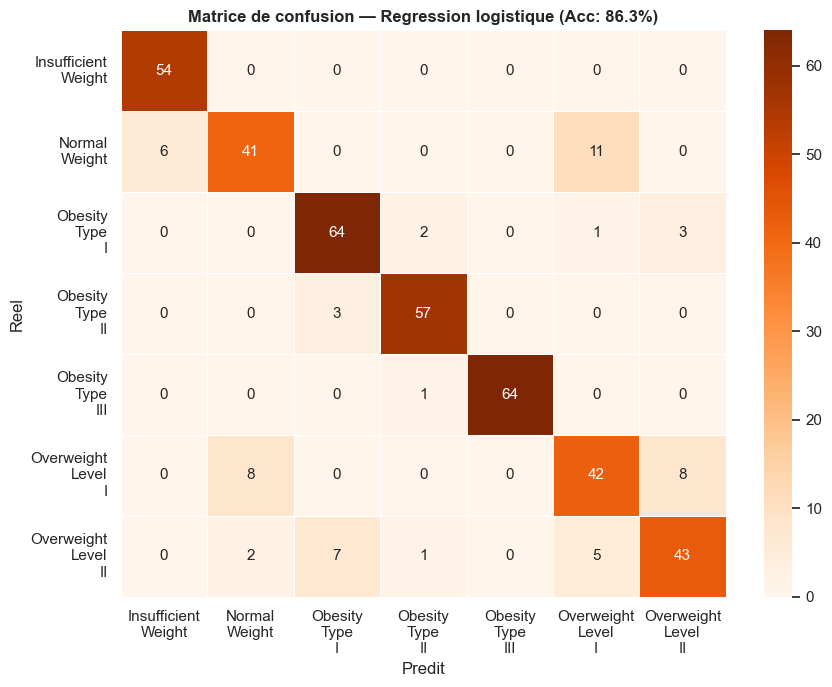

In [87]:
# Matrice de confusion Regression logistique
fig, ax = plt.subplots(figsize=(9, 7))
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=ax, linewidths=0.5, linecolor='white',
            xticklabels=[n.replace('_', '\n') for n in noms_classes],
            yticklabels=[n.replace('_', '\n') for n in noms_classes])
ax.set_xlabel('Predit')
ax.set_ylabel('Reel')
ax.set_title(f'Matrice de confusion — Regression logistique (Acc: {acc_lr:.1%})', fontweight='bold')
plt.tight_layout()
plt.show()

In [89]:
# --- XGBoost ---
# La variable cible est deja numerique (0-6), pas besoin de re-encoder
xgb_model = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                           random_state=42, eval_metric='mlogloss', verbosity=0)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost — Accuracy : {acc_xgb:.1%}\n")
print(classification_report(y_test, y_pred_xgb, target_names=noms_classes))

XGBoost — Accuracy : 95.5%

                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.93      0.95        54
      Normal_Weight       0.85      0.97      0.90        58
     Obesity_Type_I       0.96      0.97      0.96        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.96      0.90      0.93        58
Overweight_Level_II       0.96      0.95      0.96        58

           accuracy                           0.96       423
          macro avg       0.96      0.95      0.95       423
       weighted avg       0.96      0.96      0.96       423



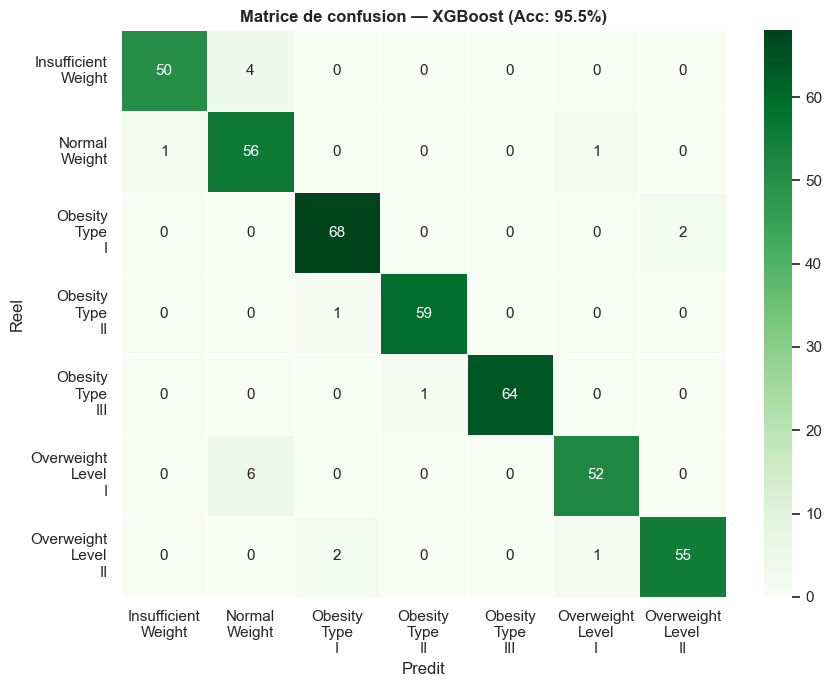

In [90]:
# Matrice de confusion XGBoost
fig, ax = plt.subplots(figsize=(9, 7))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=ax, linewidths=0.5, linecolor='white',
            xticklabels=[n.replace('_', '\n') for n in noms_classes],
            yticklabels=[n.replace('_', '\n') for n in noms_classes])
ax.set_xlabel('Predit')
ax.set_ylabel('Reel')
ax.set_title(f'Matrice de confusion — XGBoost (Acc: {acc_xgb:.1%})', fontweight='bold')
plt.tight_layout()
plt.show()

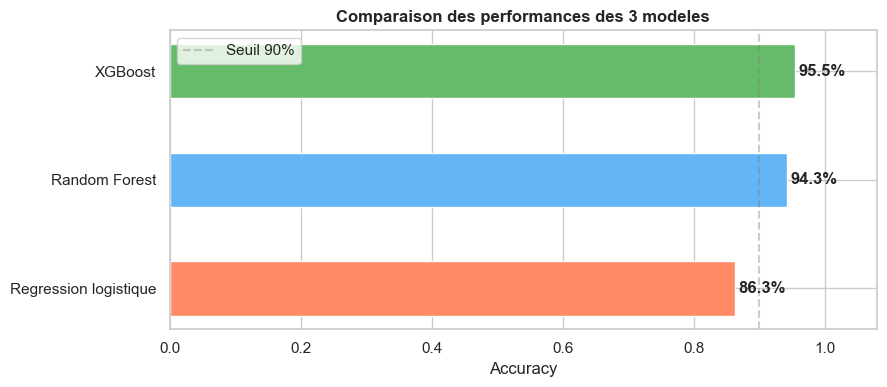


Meilleur modele : XGBoost (95.5%)


In [91]:
# Comparaison visuelle des 3 modeles
resultats = pd.DataFrame({
    'Modele': ['Random Forest', 'Regression logistique', 'XGBoost'],
    'Accuracy': [acc_rf, acc_lr, acc_xgb]
}).sort_values('Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
couleurs = ['#FF8A65', '#64B5F6', '#66BB6A']
bars = ax.barh(resultats['Modele'], resultats['Accuracy'],
               color=couleurs, edgecolor='white', height=0.5)

for bar, val in zip(bars, resultats['Accuracy']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontweight='bold', fontsize=12)

ax.set_xlim(0, 1.08)
ax.set_xlabel('Accuracy')
ax.set_title('Comparaison des performances des 3 modeles', fontweight='bold')
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4, label='Seuil 90%')
ax.legend()
plt.tight_layout()
plt.show()

meilleur = resultats.iloc[-1]
print(f"\nMeilleur modele : {meilleur['Modele']} ({meilleur['Accuracy']:.1%})")

Les trois modeles atteignent de bonnes performances, ce qui confirme que les variables du dataset permettent de predire le niveau d'obesite.

La **regression logistique**, etant un modele lineaire, a tendance a moins bien performer car les relations entre les variables et l'obesite ne sont pas purement lineaires. Elle reste cependant un bon point de reference.

Le **Random Forest** et **XGBoost**, qui capturent les interactions non-lineaires entre variables, obtiennent de meilleurs scores. XGBoost a souvent un leger avantage grace a son mecanisme de boosting qui optimise iterativement les erreurs.

## 8 — Conclusion

### Ce que cette analyse nous apprend

1. Le **poids** et le **BMI** sont, logiquement, les variables les plus discriminantes pour le niveau de corpulence.
2. Les **antecedents familiaux de surpoids** sont tres fortement associes aux classes obeses (Chi2 significatif, bon V de Cramer). Cela peut refleter a la fois une composante genetique et un environnement familial partage (memes habitudes alimentaires, meme sedentarite).
3. L'**activite physique** (FAF) varie significativement entre les groupes (ANOVA, p < 0.05). Les individus en poids normal ou sous-poids tendent a etre plus actifs.
4. Le **mode de transport** s'associe lui aussi a l'obesite : l'automobile est surrepresentee chez les personnes obeses.
5. La **consommation d'aliments gras** est liee a un BMI plus eleve, mais la taille de l'effet reste moderee.
6. Les **3 modeles** (Random Forest, Regression logistique, XGBoost) confirment ces resultats avec de bonnes performances de classification.

### Limites a garder en tete

- **77 % des donnees sont synthetiques** (SMOTE). Meme si SMOTE est une technique reconnue, les donnees generees ne remplacent pas des observations reelles. Certaines combinaisons de valeurs peuvent etre artificielles.
- **Biais geographique** : le questionnaire ne couvre que la Colombie, le Mexique et le Perou. Les resultats ne sont pas forcement generalisables a d'autres populations.
- **Auto-declaration** : les repondants declarent eux-memes leur poids, taille et habitudes, ce qui introduit un biais de declaration.
- **Correlation ne veut pas dire causalite** : cette etude transversale ne permet pas de conclure que la voiture *cause* l'obesite, seulement qu'il y a une association.
- **Variables manquantes** : les revenus, le niveau d'education, les predispositions genetiques precises ou encore les traitements medicaux ne figurent pas dans le dataset.

### Pistes pour la suite

- Tester d'autres modeles (SVM, reseaux de neurones) pour comparer.
- Collecter davantage de donnees reelles pour reduire la dependance a SMOTE.
- Ajouter des variables socio-economiques.
- Envisager une etude longitudinale pour aller vers des conclusions causales.